Cloning into 'yolov5'...
remote: Enumerating objects: 17483, done.
remote: Total 17483 (delta 0), reused 0 (delta 0), pack-reused 17483 (from 1)
Receiving objects: 100% (17483/17483), 16.58 MiB | 20.53 MiB/s, done.
Resolving deltas: 100% (11991/11991), done.
/content/yolov5/yolov5


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-5-29 Python-3.11.12 torch-2.6.0+cu124 CPU

100%|██████████| 14.1M/14.1M [00:00<00:00, 123MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 720x1280 2 persons, 1 tie, 1 cell phone
Speed: 806.0ms pre-process, 375.9ms inference, 6.6ms NMS per image at shape (1, 3, 384, 640)


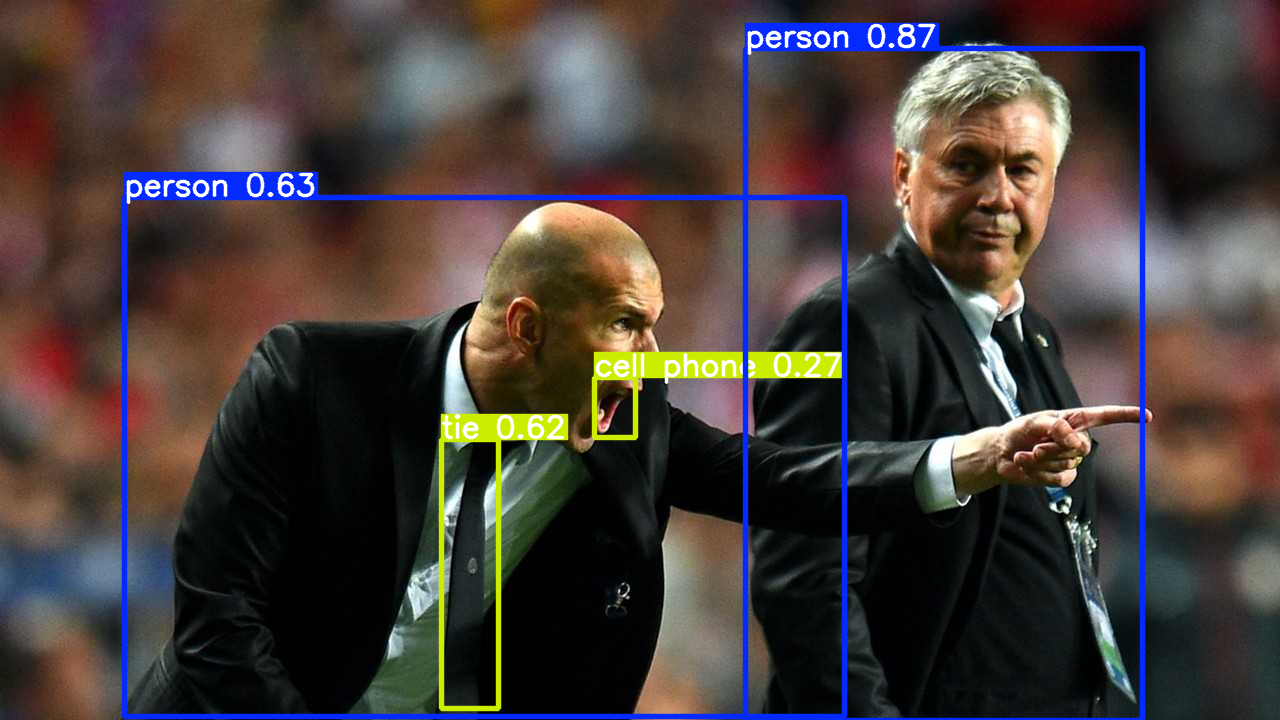

In [4]:
!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5
%pip install -r requirements.txt

import torch
model=torch.hub.load('ultralytics/yolov5','yolov5s',pretrained=True)

#test img in the repo
results = model('https://ultralytics.com/images/zidane.jpg')
results.print()
results.show()

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 1572x1170 1 cat
Speed: 74.9ms pre-process, 651.4ms inference, 5.0ms NMS per image at shape (1, 3, 640, 480)


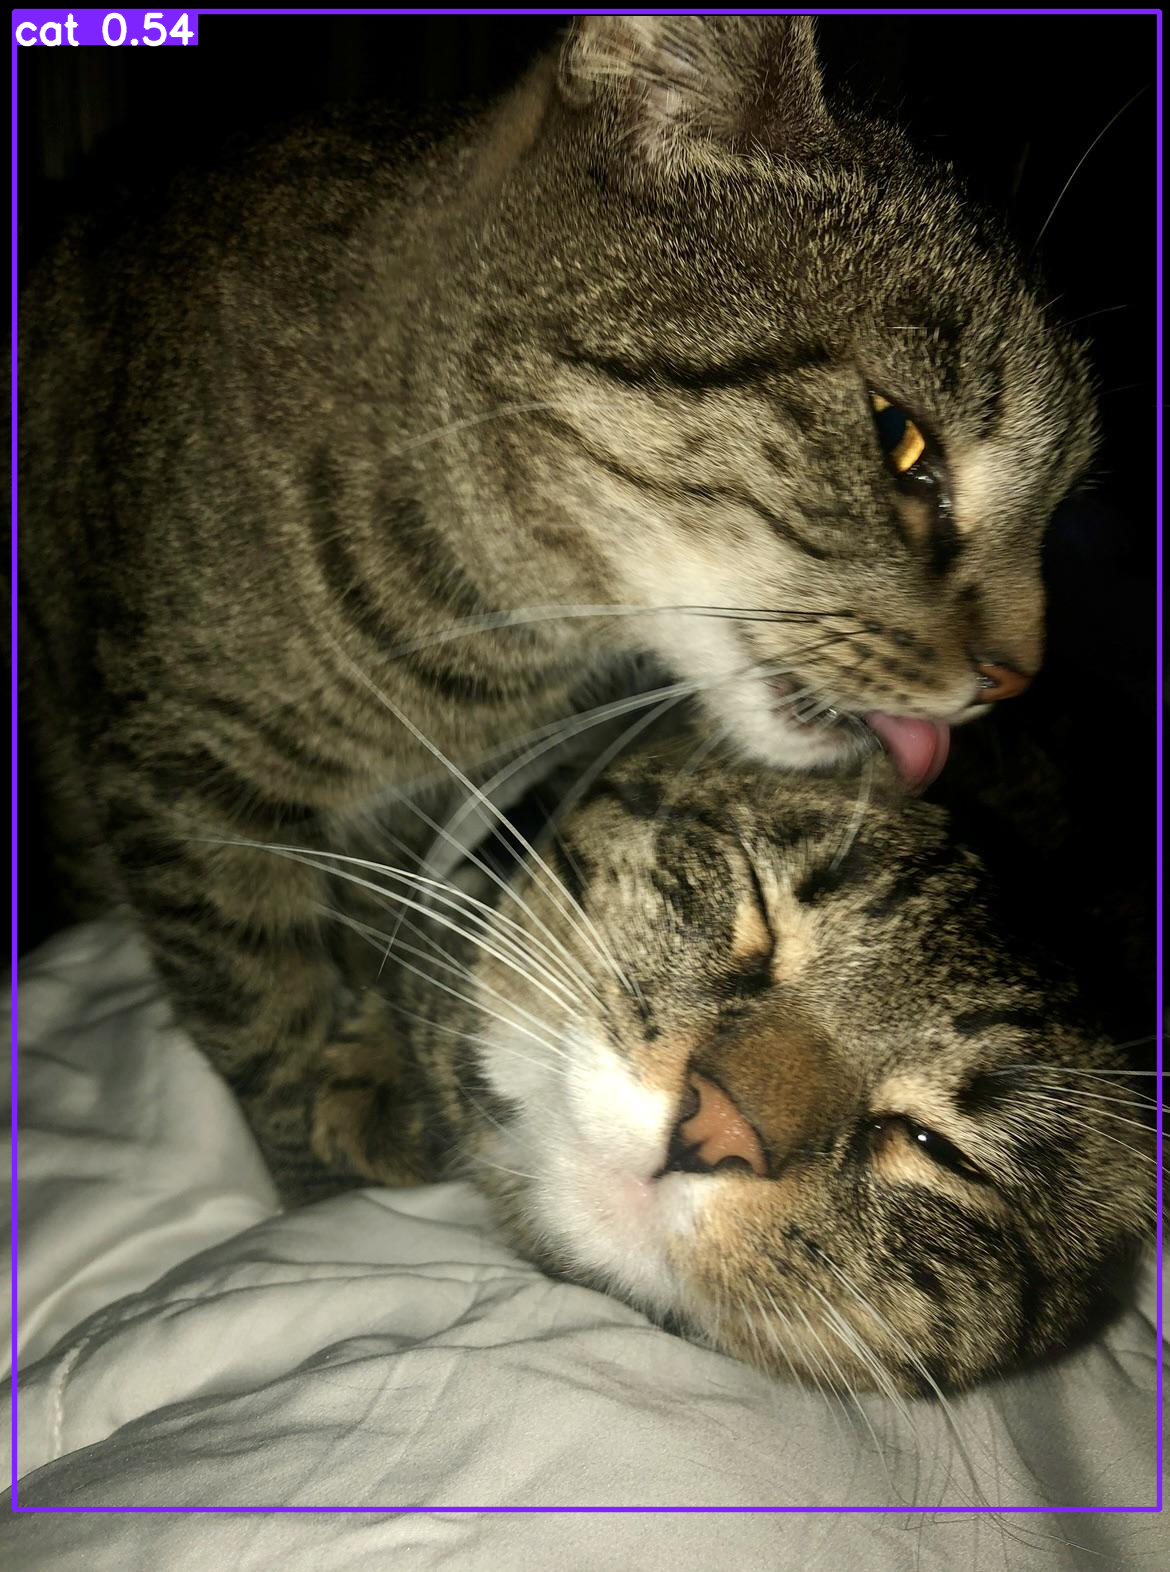

In [5]:
results = model('/content/cat_test.jpeg')
results.print()
results.show()

YOLO imp

In [1]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False) #no bias
        self.bn = nn.BatchNorm2d(out_channels)
        self.leaky = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.leaky(self.bn(self.conv(x)))

class YOLOTiny(nn.Module):
    def __init__(self, num_classes=1, num_anchors=3):
        super(YOLOTiny, self).__init__()
        self.backbone = nn.Sequential(
            ConvBlock(3, 16, 3, 1, 1),  #can  see the in_chan=out_chan_prev

            #using the formula for o/p => ((n_h+2*p-f)/stride)+1 => 'SAME' type conv involved => 2p-f+1=0
            #dimensions are maintained

            nn.MaxPool2d(2, 2),

            #(416-2)/2 +1 => 208

            ConvBlock(16, 32, 3, 1, 1),  #208
            nn.MaxPool2d(2, 2),  # floor(206/2) +1 => 104

            ConvBlock(32, 64, 3, 1, 1), #104
            nn.MaxPool2d(2, 2),  # 52

            ConvBlock(64, 128, 3, 1, 1), #52
            nn.MaxPool2d(2, 2),  # 26

            ConvBlock(128, 256, 3, 1, 1), #26
            nn.MaxPool2d(2, 2),  # 13

            ConvBlock(256, 512, 3, 1, 1) #13
        )

        self.head = nn.Sequential(
            nn.Conv2d(512, 256, 3, 1, 1),  #13
            nn.LeakyReLU(0.1),  #13
            nn.Conv2d(256, num_anchors * (5 + num_classes), 1)  #[tx,ty,tw,th,obj_confid,{classes}]  #13
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x  # Output shape: [B, 3*(5+num_classes), 13, 13]

# Test
model = YOLOTiny(num_classes=10)
x = torch.randn(1, 3, 416, 416)
out = model(x)
print(out.shape)  # ive changed to 10 => Expected: [1, anchr*(5+num_classes), 13, 13] → 3 anchors × (5+1 classes)


torch.Size([1, 45, 13, 13])
